In [ ]:
import os
from google.colab import drive

# Google Drive'a bağlanın
drive.mount('/content/drive')

Mounted at /content/drive


# ResNet50': ResNet50  200 **epoch**

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
94765736/94765736 [==============================] - 0s 0us/step
Epoch 1/200
18/18 [==============================] - ETA: 0s - loss: 1.0263 - accuracy: 0.4789

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


18/18 [==============================] - 36s 2s/step - loss: 1.0263 - accuracy: 0.4789 - val_loss: 0.7003 - val_accuracy: 0.5625
Epoch 2/200
18/18 [==============================] - 6s 330ms/step - loss: 1.0518 - accuracy: 0.4366 - val_loss: 0.7138 - val_accuracy: 0.5000
Epoch 3/200
18/18 [==============================] - 6s 323ms/step - loss: 0.8680 - accuracy: 0.4930 - val_loss: 0.7591 - val_accuracy: 0.5000
Epoch 4/200
18/18 [==============================] - 6s 325ms/step - loss: 0.7188 - accuracy: 0.5211 - val_loss: 0.7591 - val_accuracy: 0.4375
Epoch 5/200
18/18 [==============================] - 6s 353ms/step - loss: 0.7506 - accuracy: 0.4930 - val_loss: 0.6829 - val_accuracy: 0.6875
Epoch 6/200
18/18 [==============================] - 6s 327ms/step - loss: 0.8300 - accuracy: 0.5211 - val_loss: 1.0358 - val_accuracy: 0.5000
Epoch 7/200
18/18 [==============================] - 6s 324ms/step - loss: 0.7703 - accuracy: 0.5775 - val_loss: 0.7882 - val_accuracy: 0.5000
Epoch 8/200
1

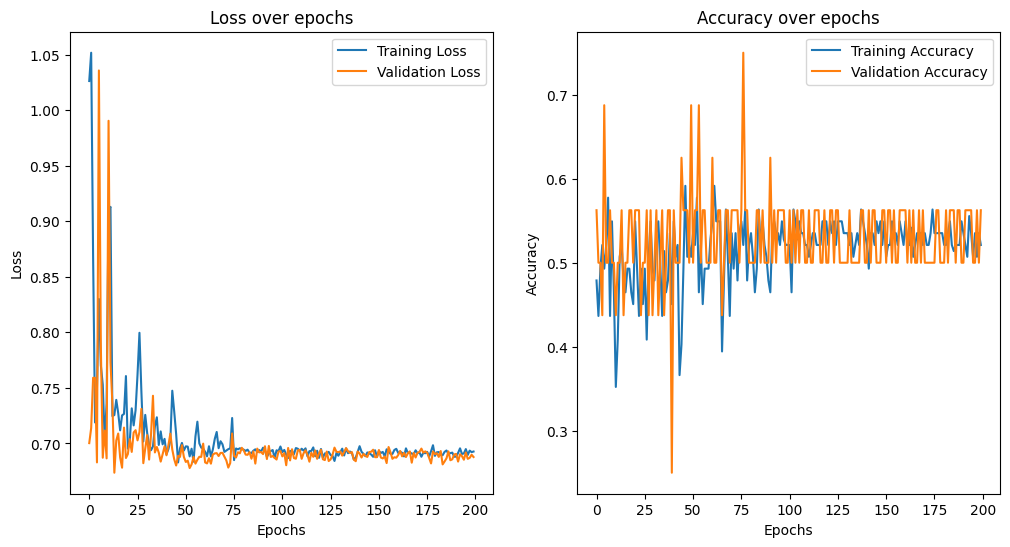

5/5 [==============================] - 2s 210ms/step
Training Loss: 0.6926891803741455
Validation Loss: 0.6877487897872925
Training Accuracy: 0.5211267471313477
Validation Accuracy: 0.5625
Weighted Precision: 0.5203619909502263
Weighted Recall: 0.5294117647058824
Weighted F1 Score: 0.49376114081996436
Micro Precision: 0.5294117647058824
Micro Recall: 0.5294117647058824
Micro F1 Score: 0.5294117647058824
Macro Precision: 0.5192307692307692
Macro Recall: 0.5138888888888888
Macro F1 Score: 0.48484848484848486
Precision (None): [0.5        0.53846154]
Recall (None): [0.25       0.77777778]
F1 Score (None): [0.33333333 0.63636364]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
model_name = 'ResNet50'
activation = 'relu'
dropout_rate = 0.0
learning_rate = 0.001
epochs = 200

# Build model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=activation)(x)
x = Dropout(dropout_rate)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[model_checkpoint],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Load the best model weights
model.load_weights('best_model.h5')

# Evaluate the model
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **InceptionV3 200 epoch**

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
87910968/87910968 [==============================] - 0s 0us/step
Epoch 1/200
18/18 [==============================] - ETA: 0s - loss: 120.3459 - accuracy: 0.5915

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


18/18 [==============================] - 12s 450ms/step - loss: 120.3459 - accuracy: 0.5915 - val_loss: 67.8833 - val_accuracy: 0.4375
Epoch 2/200
18/18 [==============================] - 6s 333ms/step - loss: 21.4935 - accuracy: 0.4648 - val_loss: 16.8804 - val_accuracy: 0.5000
Epoch 3/200
18/18 [==============================] - 6s 300ms/step - loss: 4.0061 - accuracy: 0.4930 - val_loss: 0.7000 - val_accuracy: 0.5000
Epoch 4/200
18/18 [==============================] - 5s 300ms/step - loss: 1.4104 - accuracy: 0.4507 - val_loss: 0.7066 - val_accuracy: 0.4375
Epoch 5/200
18/18 [==============================] - 6s 330ms/step - loss: 0.6977 - accuracy: 0.4930 - val_loss: 0.6872 - val_accuracy: 0.5625
Epoch 6/200
18/18 [==============================] - 6s 338ms/step - loss: 0.6912 - accuracy: 0.5493 - val_loss: 0.6991 - val_accuracy: 0.5000
Epoch 7/200
18/18 [==============================] - 5s 301ms/step - loss: 0.6953 - accuracy: 0.5211 - val_loss: 0.6947 - val_accuracy: 0.5000
Epoch

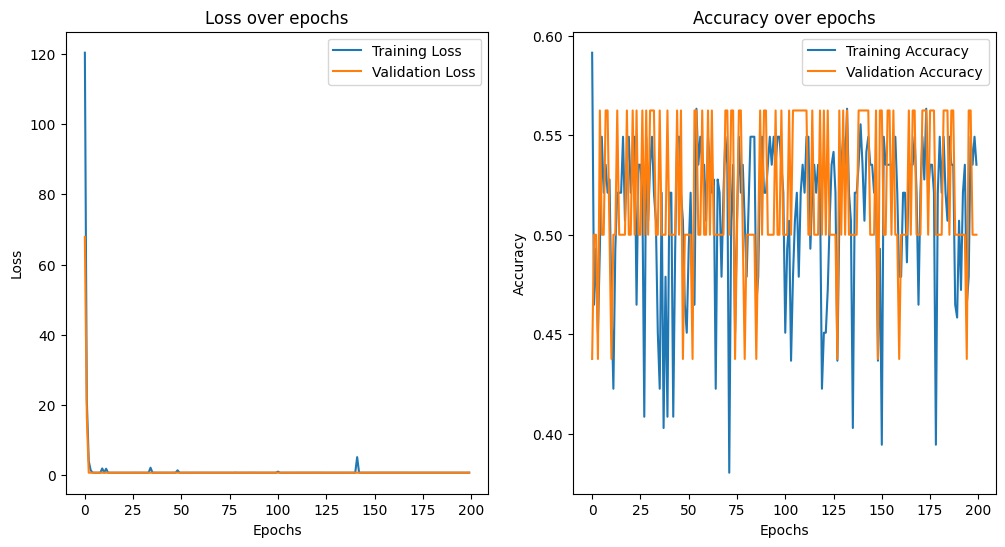

5/5 [==============================] - 2s 192ms/step
Training Loss: 0.7022792100906372
Validation Loss: 0.7038518190383911
Training Accuracy: 0.5352112650871277
Validation Accuracy: 0.5
Weighted Precision: 0.28027681660899656
Weighted Recall: 0.5294117647058824
Weighted F1 Score: 0.36651583710407243
Micro Precision: 0.5294117647058824
Micro Recall: 0.5294117647058824
Micro F1 Score: 0.5294117647058824
Macro Precision: 0.2647058823529412
Macro Recall: 0.5
Macro F1 Score: 0.3461538461538462
Precision (None): [0.         0.52941176]
Recall (None): [0. 1.]
F1 Score (None): [0.         0.69230769]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
model_name = 'InceptionV3'
activation = 'relu'
dropout_rate = 0.0
learning_rate = 0.1
epochs = 200

# Build model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=activation)(x)
x = Dropout(dropout_rate)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[model_checkpoint],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Load the best model weights
model.load_weights('best_model.h5')

# Evaluate the model
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **'DenseNet121' 200 EPOCH**

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
29084464/29084464 [==============================] - 0s 0us/step
Epoch 1/200
18/18 [==============================] - ETA: 0s - loss: 0.8961 - accuracy: 0.5634

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


18/18 [==============================] - 15s 516ms/step - loss: 0.8961 - accuracy: 0.5634 - val_loss: 0.8973 - val_accuracy: 0.5625
Epoch 2/200
18/18 [==============================] - 6s 323ms/step - loss: 0.7838 - accuracy: 0.6479 - val_loss: 0.7084 - val_accuracy: 0.5625
Epoch 3/200
18/18 [==============================] - 6s 325ms/step - loss: 0.7458 - accuracy: 0.5493 - val_loss: 0.7346 - val_accuracy: 0.5000
Epoch 4/200
18/18 [==============================] - 6s 355ms/step - loss: 0.6336 - accuracy: 0.6761 - val_loss: 0.6274 - val_accuracy: 0.6875
Epoch 5/200
18/18 [==============================] - 6s 327ms/step - loss: 0.5662 - accuracy: 0.7465 - val_loss: 0.8421 - val_accuracy: 0.3125
Epoch 6/200
18/18 [==============================] - 6s 323ms/step - loss: 0.5540 - accuracy: 0.6944 - val_loss: 0.8911 - val_accuracy: 0.4375
Epoch 7/200
18/18 [==============================] - 6s 325ms/step - loss: 0.5257 - accuracy: 0.7465 - val_loss: 0.8237 - val_accuracy: 0.5625
Epoch 8/20

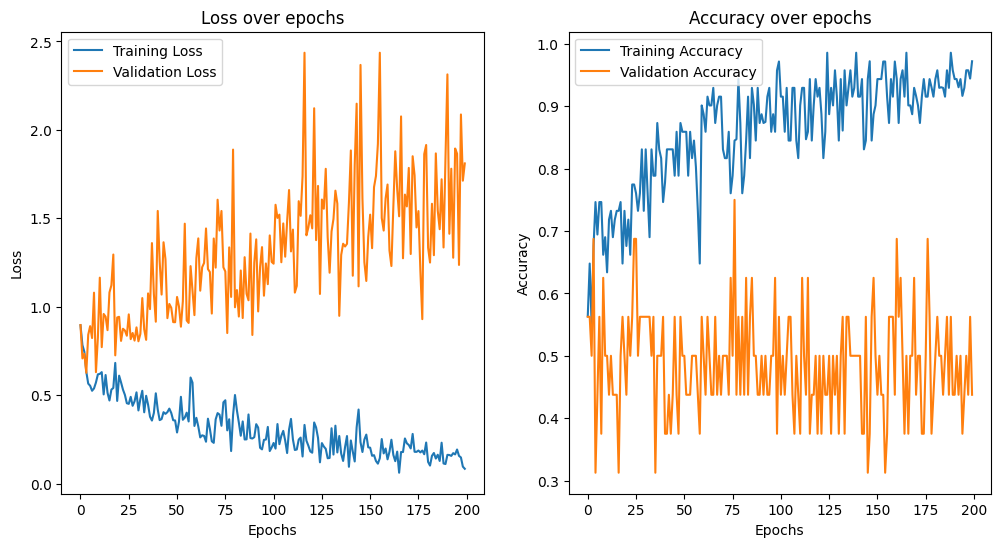

5/5 [==============================] - 3s 218ms/step
Training Loss: 0.08475962281227112
Validation Loss: 1.8105432987213135
Training Accuracy: 0.9722222089767456
Validation Accuracy: 0.4375
Weighted Precision: 0.35539215686274506
Weighted Recall: 0.35294117647058826
Weighted F1 Score: 0.35294117647058826
Micro Precision: 0.35294117647058826
Micro Recall: 0.35294117647058826
Micro F1 Score: 0.35294117647058826
Macro Precision: 0.35416666666666663
Macro Recall: 0.35416666666666663
Macro F1 Score: 0.35294117647058826
Precision (None): [0.33333333 0.375     ]
Recall (None): [0.375      0.33333333]
F1 Score (None): [0.35294118 0.35294118]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
model_name = 'DenseNet121'
activation = 'tanh'
dropout_rate = 0.1
learning_rate = 0.001
epochs = 200

# Build model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=activation)(x)
x = Dropout(dropout_rate)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[model_checkpoint],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Load the best model weights
model.load_weights('best_model.h5')

# Evaluate the model
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **'DenseNet169' 200 epoch **

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
51877672/51877672 [==============================] - 0s 0us/step
Epoch 1/200
18/18 [==============================] - ETA: 0s - loss: 1.2421 - accuracy: 0.4085

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


18/18 [==============================] - 18s 553ms/step - loss: 1.2421 - accuracy: 0.4085 - val_loss: 0.6911 - val_accuracy: 0.5625
Epoch 2/200
18/18 [==============================] - 6s 359ms/step - loss: 0.6419 - accuracy: 0.6479 - val_loss: 0.8516 - val_accuracy: 0.5000
Epoch 3/200
18/18 [==============================] - 6s 337ms/step - loss: 0.7478 - accuracy: 0.5915 - val_loss: 0.8566 - val_accuracy: 0.4375
Epoch 4/200
18/18 [==============================] - 6s 335ms/step - loss: 0.6743 - accuracy: 0.6338 - val_loss: 0.9413 - val_accuracy: 0.3750
Epoch 5/200
18/18 [==============================] - 6s 344ms/step - loss: 0.6119 - accuracy: 0.6620 - val_loss: 1.3568 - val_accuracy: 0.5000
Epoch 6/200
18/18 [==============================] - 6s 334ms/step - loss: 0.7841 - accuracy: 0.5775 - val_loss: 0.9041 - val_accuracy: 0.4375
Epoch 7/200
18/18 [==============================] - 6s 339ms/step - loss: 0.6257 - accuracy: 0.6620 - val_loss: 0.9136 - val_accuracy: 0.4375
Epoch 8/20

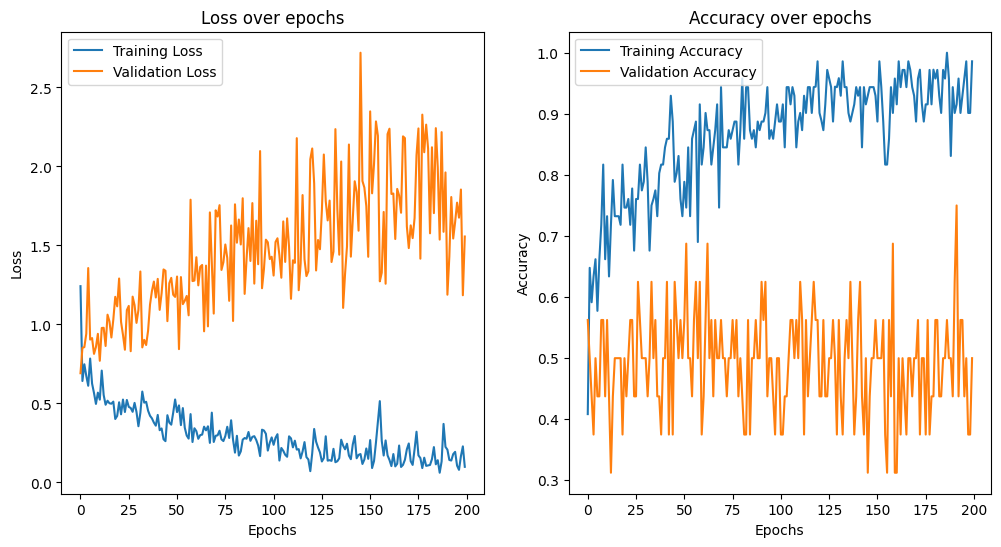

5/5 [==============================] - 4s 223ms/step
Training Loss: 0.09875927865505219
Validation Loss: 1.556376338005066
Training Accuracy: 0.98591548204422
Validation Accuracy: 0.5
Weighted Precision: 0.5923202614379085
Weighted Recall: 0.5882352941176471
Weighted F1 Score: 0.5882352941176471
Micro Precision: 0.5882352941176471
Micro Recall: 0.5882352941176471
Micro F1 Score: 0.5882352941176471
Macro Precision: 0.5902777777777778
Macro Recall: 0.5902777777777778
Macro F1 Score: 0.5882352941176471
Precision (None): [0.55555556 0.625     ]
Recall (None): [0.625      0.55555556]
F1 Score (None): [0.58823529 0.58823529]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
model_name = 'DenseNet169'
activation = 'relu'
dropout_rate = 0.0
learning_rate = 0.001
epochs = 200

# Build model
base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=activation)(x)
x = Dropout(dropout_rate)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[model_checkpoint],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Load the best model weights
model.load_weights('best_model.h5')

# Evaluate the model
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **'DenseNet201 200 epoch**

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
74836368/74836368 [==============================] - 0s 0us/step
Epoch 1/200
18/18 [==============================] - ETA: 0s - loss: 118.7126 - accuracy: 0.4930

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


18/18 [==============================] - 21s 615ms/step - loss: 118.7126 - accuracy: 0.4930 - val_loss: 8.4368 - val_accuracy: 0.5000
Epoch 2/200
18/18 [==============================] - 8s 444ms/step - loss: 5.3607 - accuracy: 0.5634 - val_loss: 5.2030 - val_accuracy: 0.5625
Epoch 3/200
18/18 [==============================] - 7s 365ms/step - loss: 3.7666 - accuracy: 0.5211 - val_loss: 0.9114 - val_accuracy: 0.5000
Epoch 4/200
18/18 [==============================] - 8s 419ms/step - loss: 1.2961 - accuracy: 0.5915 - val_loss: 0.6944 - val_accuracy: 0.6250
Epoch 5/200
18/18 [==============================] - 7s 360ms/step - loss: 1.0274 - accuracy: 0.4648 - val_loss: 0.6959 - val_accuracy: 0.5625
Epoch 6/200
18/18 [==============================] - 7s 366ms/step - loss: 0.7190 - accuracy: 0.4648 - val_loss: 0.6591 - val_accuracy: 0.6250
Epoch 7/200
18/18 [==============================] - 6s 352ms/step - loss: 0.8014 - accuracy: 0.5211 - val_loss: 0.6657 - val_accuracy: 0.5000
Epoch 8/

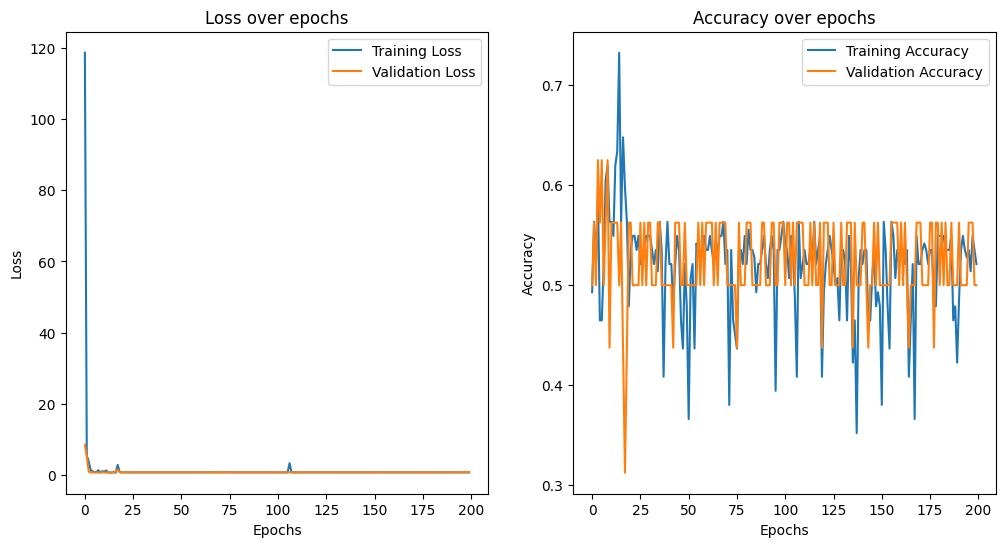

5/5 [==============================] - 4s 254ms/step
Training Loss: 0.6968488097190857
Validation Loss: 0.6954883337020874
Training Accuracy: 0.5211267471313477
Validation Accuracy: 0.5
Weighted Precision: 0.48431372549019613
Weighted Recall: 0.47058823529411764
Weighted F1 Score: 0.3827016972797023
Micro Precision: 0.47058823529411764
Micro Recall: 0.47058823529411764
Micro F1 Score: 0.47058823529411764
Macro Precision: 0.48333333333333334
Macro Recall: 0.4930555555555556
Macro F1 Score: 0.39525691699604737
Precision (None): [0.46666667 0.5       ]
Recall (None): [0.875      0.11111111]
F1 Score (None): [0.60869565 0.18181818]


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
model_name = 'DenseNet201'
activation = 'relu'
dropout_rate = 0.1
learning_rate = 0.1
epochs = 200

# Build model
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=activation)(x)
x = Dropout(dropout_rate)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[model_checkpoint],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Load the best model weights
model.load_weights('best_model.h5')

# Evaluate the model
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)
